In [180]:
import pandas as pd
df = pd.read_csv(r"/home/chris/Documents/Broadway Python/Lesson 1/Machine Learning/Linear Regression/Salary Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [181]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [182]:
df.describe(include="O")

/tmp/ipykernel_6645/504318277.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="O")


,Gender,Education Level,Job Title
count,373,373,373
unique,2,3,174
top,Male,Bachelor's,Director of Marketing
freq,194,224,12


In [183]:
df.drop_duplicates(inplace=True)

In [184]:
df.isnull().sum()

Age                    1
Gender                 1
Education Level        1
Job Title              1
Years of Experience    1
Salary                 1
dtype: int64

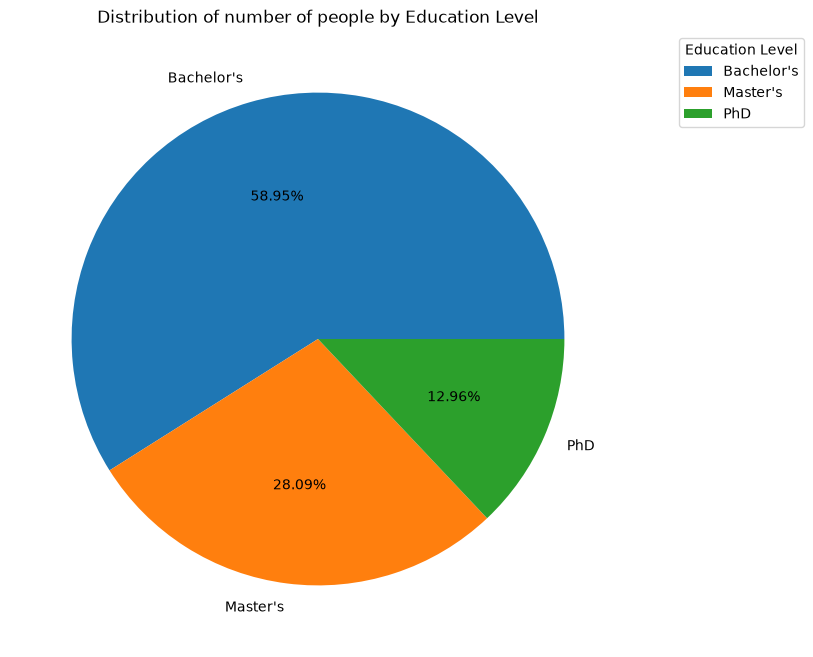

In [185]:
#no of children pie plot
import matplotlib.pyplot as plt
education_level_count =df['Education Level'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(education_level_count.values, labels=education_level_count.index.values, autopct='%1.2f%%')
plt.title('Distribution of number of people by Education Level')
plt.legend(title='Education Level', loc='upper right' , bbox_to_anchor=(1.3, 1))
plt.show()

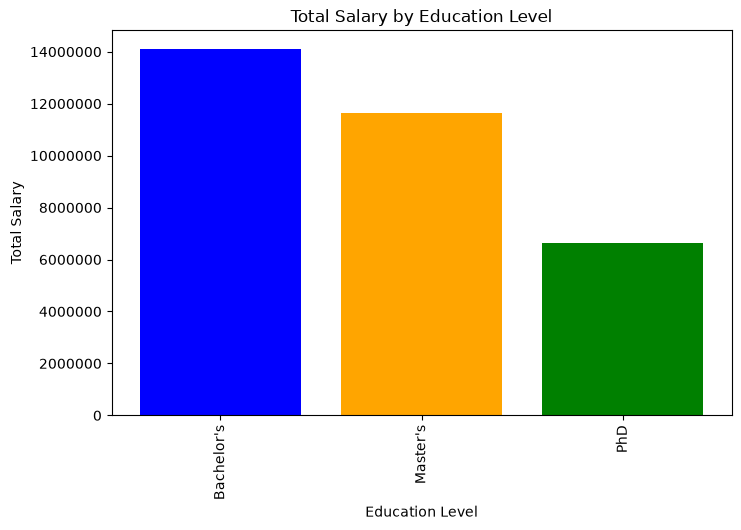

In [186]:
#region vs expenses barplot
import matplotlib.pyplot as plt

plt1 = df.groupby("Education Level")["Salary"].sum()

plt.figure(figsize=(8,5))
plt.bar(plt1.index, plt1.values, color=['blue', 'orange', 'green', 'red'])

plt.xlabel("Education Level")
plt.ylabel("Total Salary")

plt.title("Total Salary by Education Level")
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90)
plt.show()

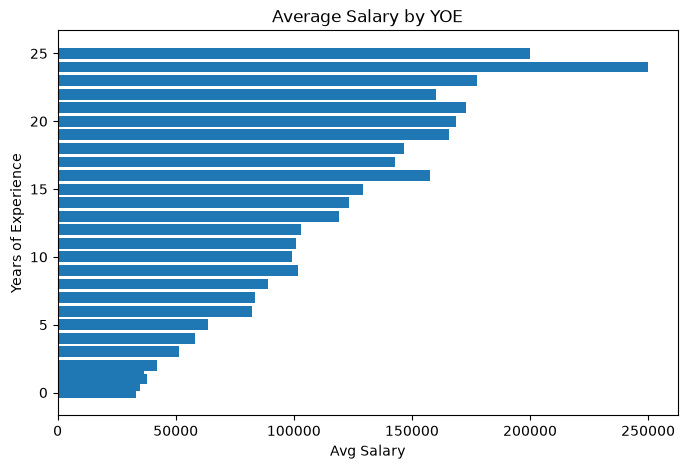

In [187]:
#region vs avg no of children
import matplotlib.pyplot as plt

plt1 = df[['Years of Experience','Salary']].groupby("Years of Experience").mean()
plt.figure(figsize=(8,5))

plt.barh(plt1.index, plt1['Salary'])

plt.xlabel("Avg Salary")
plt.ylabel("Years of Experience")
plt.title("Average Salary by YOE")
plt.show()

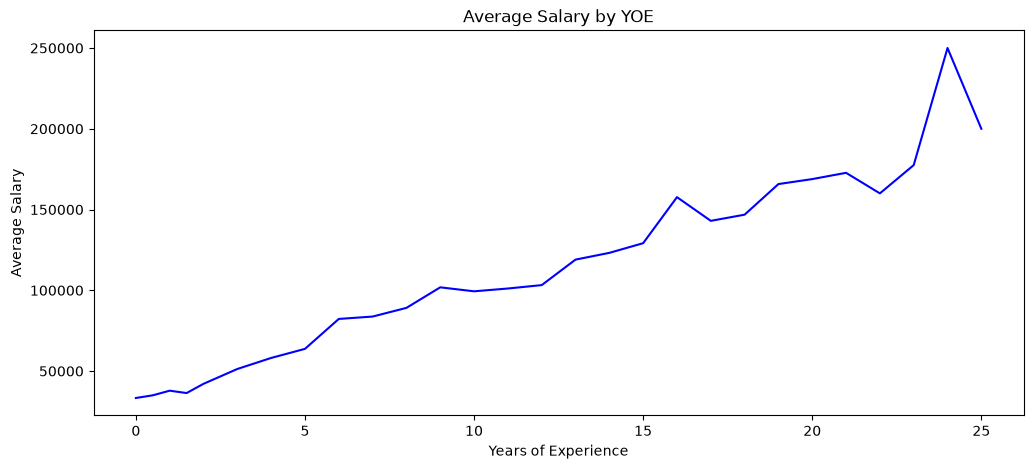

In [188]:
import seaborn as sns 
import matplotlib.pyplot as plt 

# Fix quotes for column names
plt_df = df.groupby('Years of Experience')['Salary'].mean().reset_index() 

plt.figure(figsize=(12, 5)) 

# Remove hue and palette for a simple numeric line plot
sns.lineplot(data=plt_df, x='Years of Experience', y='Salary', color='b') 

plt.title('Average Salary by YOE') 
plt.xlabel('Years of Experience') 
plt.ylabel('Average Salary') 
plt.show()


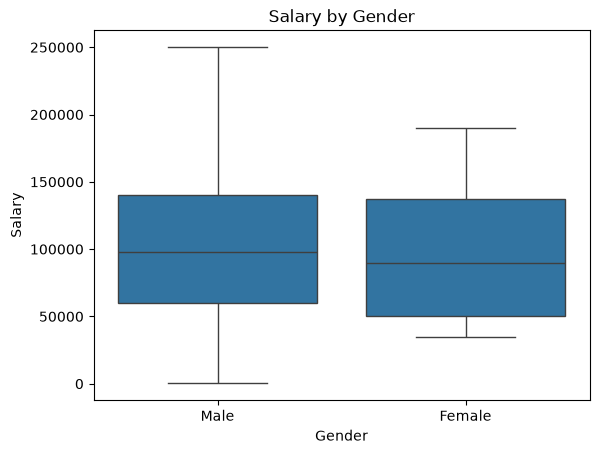

In [189]:
sns.boxplot(data=df, x='Gender', y='Salary')
plt.title("Salary by Gender")
plt.show()

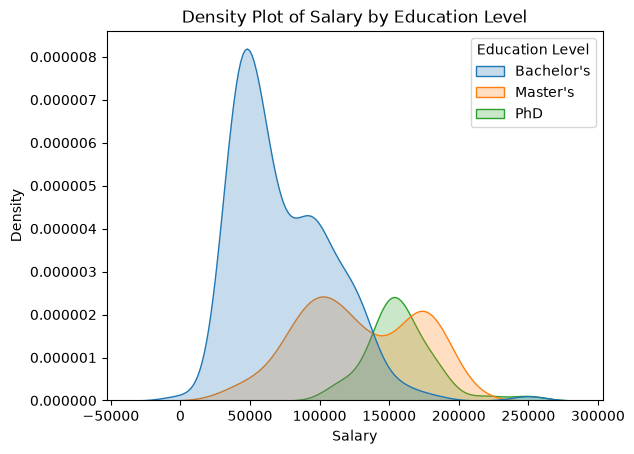

In [190]:
sns.kdeplot(data=df, x='Salary', hue='Education Level', fill=True)
plt.title("Density Plot of Salary by Education Level")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

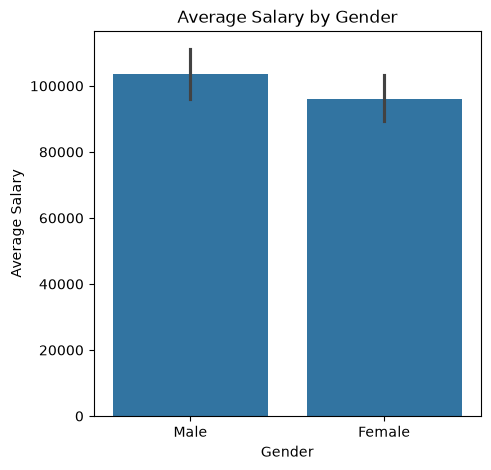

In [191]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
sns.barplot(data=df, x='Gender', y='Salary')
plt.title("Average Salary by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Salary")
plt.show()

In [192]:
selected_columns=df[['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']]

<Figure size 1500x1500 with 0 Axes>

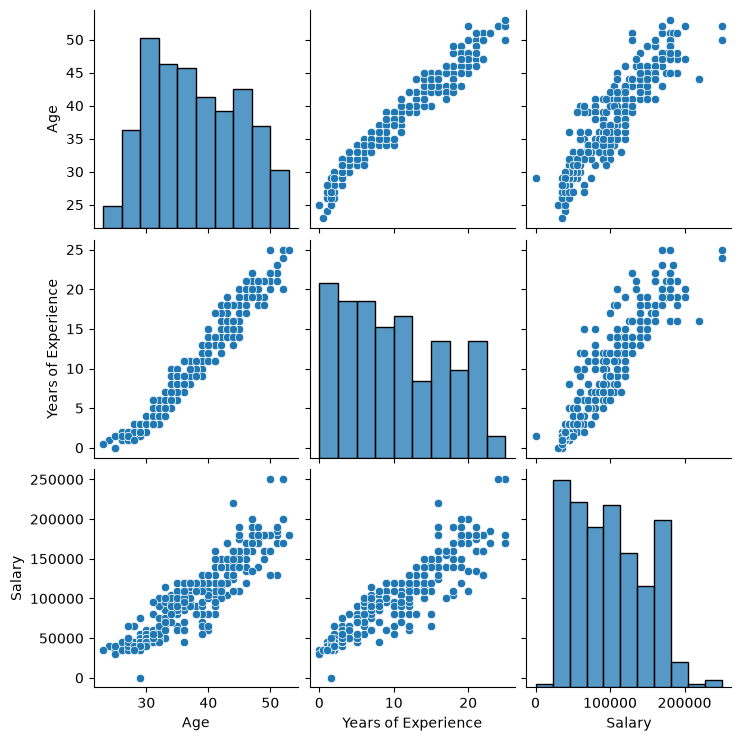

In [193]:
plt.figure(figsize=(15, 15))
sns.pairplot(selected_columns)
plt.show()

In [194]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
348,28.0,Female,Bachelor's,Junior Operations Manager,1.0,35000.0
349,36.0,Male,Bachelor's,Senior Business Development Manager,8.0,110000.0
350,44.0,Female,PhD,Senior Data Scientist,16.0,160000.0
351,31.0,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000.0


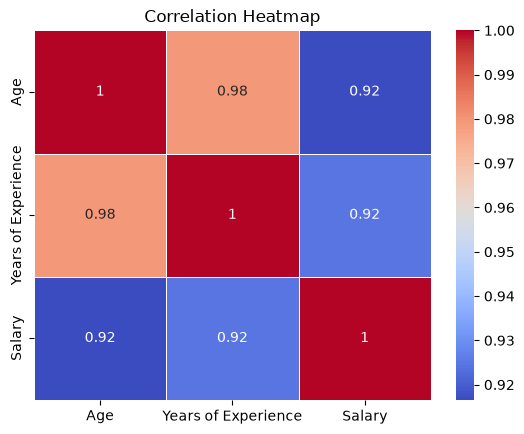

In [195]:
num_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [196]:
target_col="Salary"
corr_matrix = num_df.drop(columns=[target_col]).corr().abs()

columns_to_drop = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.8:
            columns_to_drop.append(corr_matrix.columns[i])

print(columns_to_drop)

['Years of Experience']


In [197]:
# df.reset_index(drop=True)
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
348,28.0,Female,Bachelor's,Junior Operations Manager,1.0,35000.0
349,36.0,Male,Bachelor's,Senior Business Development Manager,8.0,110000.0
350,44.0,Female,PhD,Senior Data Scientist,16.0,160000.0
351,31.0,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000.0


In [198]:
df.drop(columns=columns_to_drop, inplace=True)

In [199]:
df.drop(columns='Job Title', inplace=True)
df

,Age,Gender,Education Level,Salary
0,32.0,Male,Bachelor's,90000.0
1,28.0,Female,Master's,65000.0
2,45.0,Male,PhD,150000.0
3,36.0,Female,Bachelor's,60000.0
4,52.0,Male,Master's,200000.0
...,...,...,...,...
348,28.0,Female,Bachelor's,35000.0
349,36.0,Male,Bachelor's,110000.0
350,44.0,Female,PhD,160000.0
351,31.0,Male,Bachelor's,55000.0


In [200]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, train_size = 0.80, test_size = 0.20, random_state = 42)

In [201]:
df_train.head()

,Age,Gender,Education Level,Salary
172,NaN,NaN,NaN,NaN
183,27.0,Male,Bachelor's,40000.0
17,39.0,Male,PhD,115000.0
24,41.0,Male,Master's,140000.0
132,40.0,Female,Master's,100000.0


In [202]:
df_train.dropna(inplace=True)

In [203]:
df_train.head()

,Age,Gender,Education Level,Salary
183,27.0,Male,Bachelor's,40000.0
17,39.0,Male,PhD,115000.0
24,41.0,Male,Master's,140000.0
132,40.0,Female,Master's,100000.0
113,32.0,Male,Master's,90000.0


In [204]:
df_test.head()

,Age,Gender,Education Level,Salary
235,32.0,Male,Bachelor's,45000.0
110,42.0,Female,Master's,110000.0
249,47.0,Male,Master's,170000.0
9,38.0,Male,PhD,110000.0
93,52.0,Female,Master's,170000.0


In [205]:
df_test.dropna(inplace=True)
df_test.head()

,Age,Gender,Education Level,Salary
235,32.0,Male,Bachelor's,45000.0
110,42.0,Female,Master's,110000.0
249,47.0,Male,Master's,170000.0
9,38.0,Male,PhD,110000.0
93,52.0,Female,Master's,170000.0


In [206]:
print("the shape of the train data set is : ", df_train.shape)
print("the shape of the test data set is : ", df_test.shape)

the shape of the train data set is :  (259, 4)
the shape of the test data set is :  (65, 4)


In [207]:
# select the categorical columns
categorical_features =df_train.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove('Education Level')
categorical_features

/tmp/ipykernel_6645/3828282781.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features =df_train.select_dtypes(include=['object']).columns.tolist()


['Gender']

In [208]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# 1. Define the exact order of your categories from lowest to highest
education_order = ["Bachelor's", "Master's", 'PhD']

ct = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
        # 2. Pass the order inside a list, and explicitly name the column target
        ('oe', OrdinalEncoder(categories=[education_order]), ['Education Level'])
    ],
    remainder='passthrough'
)

# 3. Fit and transform your data splits
train_transformed = ct.fit_transform(df_train.drop('Salary', axis=1))
test_transformed = ct.transform(df_test.drop('Salary', axis=1))


In [209]:
# Encoded column names
encoded_cols = ct.named_transformers_['ohe'].get_feature_names_out(categorical_features)
print(list(encoded_cols))

['Gender_Male']


In [210]:
# Remaining columns (exclude the target 'expenses' so it isn't treated as a feature)
remaining_cols = [col for col in df.columns if col not in categorical_features and col != 'Salary']
print(list(remaining_cols))

['Age', 'Education Level']


In [211]:
# Combine names
all_cols = list(encoded_cols) + remaining_cols
all_cols

['Gender_Male', 'Age', 'Education Level']

In [212]:
# DataFrame of features only
df_train_encoded = pd.DataFrame(train_transformed, columns=all_cols)
df_test_encoded = pd.DataFrame(test_transformed, columns=all_cols)
# Re-attach the target column so the existing train_test_split + pop('expenses') flow keeps working
df_train_encoded['Salary'] = df_train['Salary'].values
df_test_encoded['Salary'] = df_test['Salary'].values

In [213]:
df_train_encoded.head()

,Gender_Male,Age,Education Level,Salary
0,1.0,0.0,27.0,40000.0
1,1.0,2.0,39.0,115000.0
2,1.0,1.0,41.0,140000.0
3,0.0,1.0,40.0,100000.0
4,1.0,1.0,32.0,90000.0


In [214]:
df_test_encoded.head()

,Gender_Male,Age,Education Level,Salary
0,1.0,0.0,32.0,45000.0
1,0.0,1.0,42.0,110000.0
2,1.0,1.0,47.0,170000.0
3,1.0,2.0,38.0,110000.0
4,0.0,1.0,52.0,170000.0


In [215]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Scale only features, NOT the target variable
df_train_encoded[['Age']] = scaler.fit_transform(df_train_encoded[['Age']])
df_test_encoded[['Age']] = scaler.transform(df_test_encoded[['Age']])

In [216]:
df_train_encoded

,Gender_Male,Age,Education Level,Salary
0,1.0,0.0,27.0,40000.0
1,1.0,1.0,39.0,115000.0
2,1.0,0.5,41.0,140000.0
3,0.0,0.5,40.0,100000.0
4,1.0,0.5,32.0,90000.0
...,...,...,...,...
254,0.0,1.0,50.0,180000.0
255,0.0,0.0,39.0,70000.0
256,0.0,0.0,30.0,50000.0
257,0.0,0.0,29.0,35000.0


In [217]:
df_test_encoded.head()

,Gender_Male,Age,Education Level,Salary
0,1.0,0.0,32.0,45000.0
1,0.0,0.5,42.0,110000.0
2,1.0,0.5,47.0,170000.0
3,1.0,1.0,38.0,110000.0
4,0.0,0.5,52.0,170000.0


In [218]:
y_train = df_train_encoded.pop('Salary')
X_train = df_train_encoded

In [219]:
y_test = df_test_encoded.pop('Salary')
X_test = df_test_encoded

In [220]:
X_train

,Gender_Male,Age,Education Level
0,1.0,0.0,27.0
1,1.0,1.0,39.0
2,1.0,0.5,41.0
3,0.0,0.5,40.0
4,1.0,0.5,32.0
...,...,...,...
254,0.0,1.0,50.0
255,0.0,0.0,39.0
256,0.0,0.0,30.0
257,0.0,0.0,29.0


In [221]:
# Importing RFE and LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Select top 5 features
rfe = RFE(estimator=model, n_features_to_select=3)


# Fit RFE
X_rfe = rfe.fit_transform(X_train, y_train)

# Selected feature names
selected_features = X_train.columns[rfe.support_]

print("Selected Features:")
print(list(selected_features))

Selected Features:
['Gender_Male', 'Age', 'Education Level']


In [222]:
feature_ranking = pd.DataFrame({
    'Feature': X_train.columns,
    'Selected': rfe.support_,
    'Rank': rfe.ranking_
})

feature_ranking.sort_values('Rank').reset_index(drop=True)

,Feature,Selected,Rank
0,Gender_Male,True,1
1,Age,True,1
2,Education Level,True,1


In [223]:
X_train_final = X_train[selected_features]

lr = LinearRegression()
lr.fit(X_train_final, y_train)
y_pred = lr.predict(X_test[selected_features])

In [224]:
for i, (feature, coef) in enumerate(zip(selected_features, lr.coef_), start=1):
    print(f"{feature} (m{i}) : {coef}")

print(f"Bias (b) : {lr.intercept_}")

Gender_Male (m1) : 9172.556196897669
Age (m2) : 34537.024786211325
Education Level (m3) : 5363.323366586571
Bias (b) : -114857.16067550358


In [225]:
for i in zip(y_test[10:20], y_pred[10:20]):
    print(f"Actual: {i[0]}, Predicted: {i[1]}")

Actual: 105000.0, Predicted: 110026.87247820289
Actual: 140000.0, Predicted: 138397.5798474112
Actual: 150000.0, Predicted: 114211.65355144351
Actual: 120000.0, Predicted: 133034.25648082464
Actual: 35000.0, Predicted: 35315.893588920415
Actual: 35000.0, Predicted: 33761.803052644944
Actual: 150000.0, Predicted: 144939.4455073437
Actual: 40000.0, Predicted: 36494.43588226635
Actual: 45000.0, Predicted: 35315.893588920415
Actual: 55000.0, Predicted: 49851.77315240464


In [226]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.9251223895502251
MAE: 9901.126269443672
RMSE: 13074.226333240926


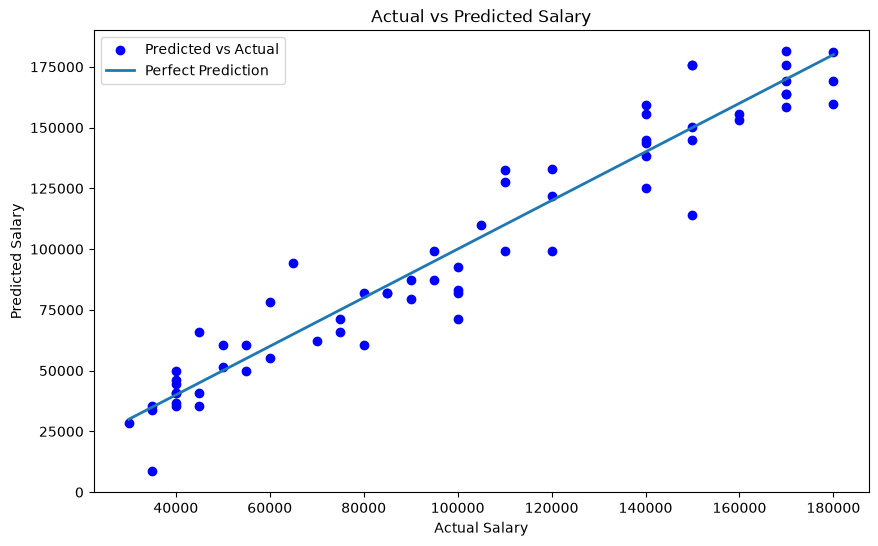

In [227]:
# line draw
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], lw=2, label='Perfect Prediction')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.show()

In [229]:
import gradio as gr
def predict_salary(gender, education_level, age):
    input_df=pd.DataFrame({
        'Gender': [gender],
        'Education Level': [education_level],
        'Age': [age]
    })
    
    # doing the transformation (encoding and scaling) on the input data
    # feature encoding
    input_transformed = ct.transform(input_df)
    all_cols = list(ct.named_transformers_['ohe'].get_feature_names_out(categorical_features)) + ['Education Level', 'Age']
    input_transformed_df = pd.DataFrame(input_transformed, columns=all_cols)
    # feature scaling
    input_transformed_df[['Age']] = scaler.transform(input_transformed_df[['Age']])
    # selecting the features which were selected by RFE
    input_final = input_transformed_df[selected_features]
    # making the prediction
    prediction = lr.predict(input_final)
    return f"Estimated Salary: {prediction[0]:,.2f}"

gr.Interface(
    fn=predict_salary,
    inputs=[
        gr.Dropdown(label="Gender", choices=["Male", "Female"]),
        gr.Dropdown(label="Education Level", choices=["Bachelor's", "Master's", "PhD"]),
        gr.Number(label="Age"),
    ],
    outputs="text",
    flagging_mode="never"
).launch()

* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.
